In [5]:
#import packages
import re #regex
import html
import pandas as pd
import numpy as np

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.utils import tokenize
from gensim.models.coherencemodel import CoherenceModel
from gensim.test.utils import datapath

#import pyLDAvis
#import pyLDAvis.gensim_models

#pyLDAvis.enable_notebook()

import matplotlib.pyplot as plt
import seaborn as sns

from num2words import num2words


In [6]:
np.random.seed(24)

In [7]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Intern\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Import dataframes

#### Publications

In [8]:
#upload dataset
pub_df = pd.read_csv('pub_df.csv')
pub_df.columns

Index(['source', 'slug', 'institution', 'news_partnership', 'story_count',
       'corpus_file', 'CITY', 'NewsOutlets2023', 'AdjCountyMin', 'news_status',
       'Adj_news_status'],
      dtype='object')

In [9]:
#create new column that is in or adjacent to a LNA
lna = []
for i, row in pub_df.iterrows():
    if row["news_status"] == 1:
        lna.append(1)
    elif row["Adj_news_status"] == 1:
        lna.append(1)
    else:
        lna.append(0)
pub_df["LNA"] = lna

In [10]:
pub_df.head()

,source,slug,institution,news_partnership,story_count,corpus_file,CITY,NewsOutlets2023,AdjCountyMin,news_status,Adj_news_status,LNA
0,The NewsHouse,the-newshouse,Syracuse University,0.0,381,publication_corpora/the-newshouse.txt,Syracuse,6.0,1.0,0.0,1.0,1
1,The Observer,the-observer,University of Illinois Springfield,0.0,10,publication_corpora/the-observer.txt,Springfield,12.0,1.0,0.0,1.0,1
2,The Observer-NDSM,the-observer,"University of Notre Dame, Saint Mary's College...",0.0,46,publication_corpora/the-observer.txt,NaN,1.0,1.0,1.0,1.0,1
3,The Observer-FU,the-observer,Fordham University,0.0,98,publication_corpora/the-observer.txt,Bronx,5.0,5.0,0.0,0.0,0
4,The Observer-CWU,the-observer,Central Washington University,0.0,10,publication_corpora/the-observer.txt,Ellensburg,2.0,1.0,0.0,1.0,1


#### Stories

In [11]:
#upload dataset
news_df = pd.read_csv('news_df.csv')
news_df.columns

Index(['source', 'title', 'link', 'published', 'captured_at', 'theme',
       'keywords', 'sentiment_label', 'sentiment_score', 'extraction_status',
       'full_text_path', 'full_text', 'slug', 'institution',
       'news_partnership', 'story_count', 'corpus_file', 'CITY',
       'NewsOutlets2023', 'AdjCountyMin', 'word_count', 'news_status',
       'Adj_news_status'],
      dtype='object')

In [12]:
#create new column that is in or adjacent to a LNA
lna = []
for i, row in news_df.iterrows():
    if row["news_status"] == 1:
        lna.append(1)
    elif row["Adj_news_status"] == 1:
        lna.append(1)
    else:
        lna.append(0)
news_df["LNA"] = lna

In [13]:
news_df.head()

,source,title,link,published,captured_at,theme,keywords,sentiment_label,sentiment_score,extraction_status,...,news_partnership,story_count,corpus_file,CITY,NewsOutlets2023,AdjCountyMin,word_count,news_status,Adj_news_status,LNA
0,Crosstown,Building is coming back in the Palisades,https://xtown.la/2025/09/30/building-pacific-p...,"Tue, 30 Sep 2025 20:59:27 +0000",2026-02-03 11:52:48,Unclassified,building | coming | back | palisades,neutral,0.0,ok,...,1.0,14.0,publication_corpora/crosstown.txt,Los Angeles,104.0,9.0,920,0.0,0.0,0
1,Crosstown,Sun is setting on new solar power in Los Angeles,https://xtown.la/2025/09/11/solar-power-los-an...,"Fri, 12 Sep 2025 02:08:41 +0000",2026-02-03 11:52:48,Conference | Collegiate | Transition | Initiat...,setting | solar | power | angeles,neutral,0.0,ok,...,1.0,14.0,publication_corpora/crosstown.txt,Los Angeles,104.0,9.0,1298,0.0,0.0,0
2,Crosstown,Crime in Los Angeles in four charts,https://xtown.la/2025/08/25/crime-in-los-angel...,"Mon, 25 Aug 2025 15:30:11 +0000",2026-02-03 11:52:48,Unclassified,crime | angeles | four | charts,neutral,0.0,ok,...,1.0,14.0,publication_corpora/crosstown.txt,Los Angeles,104.0,9.0,669,0.0,0.0,0
3,Crosstown,Los Angeles’s pool party may be coming to a close,https://xtown.la/2025/08/18/pool-permits-los-a...,"Mon, 18 Aug 2025 13:00:06 +0000",2026-02-03 11:52:48,Unclassified,angeles | pool | party | coming | close,neutral,0.0,ok,...,1.0,14.0,publication_corpora/crosstown.txt,Los Angeles,104.0,9.0,406,0.0,0.0,0
4,Crosstown,Your streetlight went dark. Could a new tariff...,https://xtown.la/2025/08/06/copper-wire-tarrif...,"Wed, 06 Aug 2025 17:01:45 +0000",2026-02-03 11:52:48,Unclassified,streetlight | went | dark | could | tariff,neutral,0.0,ok,...,1.0,14.0,publication_corpora/crosstown.txt,Los Angeles,104.0,9.0,735,0.0,0.0,0


## EDA

### Publications

In [14]:
pub_df.shape

(888, 12)

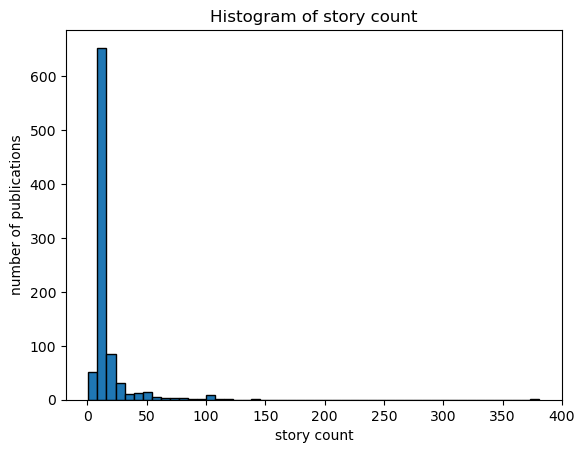

In [15]:
plt.hist(x=pub_df['story_count'], bins=50, edgecolor='black')
plt.title('Histogram of story count')
plt.xlabel('story count')
plt.ylabel('number of publications')
plt.show()

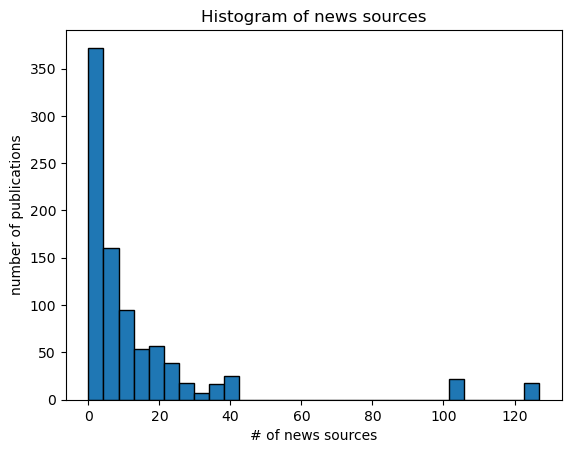

In [16]:
plt.hist(x=pub_df['NewsOutlets2023'], bins=30, edgecolor='black')
plt.title('Histogram of news sources')
plt.xlabel('# of news sources')
plt.ylabel('number of publications')
plt.show()

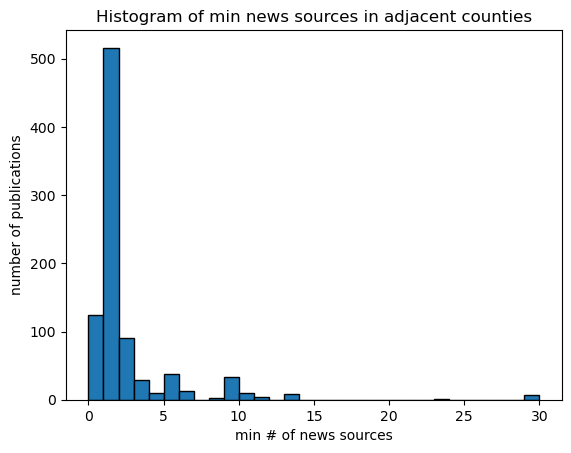

In [17]:
plt.hist(x=pub_df['AdjCountyMin'], bins=30, edgecolor='black')
plt.title('Histogram of min news sources in adjacent counties')
plt.xlabel('min # of news sources')
plt.ylabel('number of publications')
plt.show()

In [18]:
pub_df['news_partnership'].value_counts()

news_partnership
0.0    794
1.0     86
Name: count, dtype: int64

In [19]:
#average news sources in county and surounding county for each type of NP
NP_types = [0,1]
for type in NP_types:
    print(type)
    print(pub_df['news_partnership'].value_counts()[type])
    print(pub_df.loc[pub_df['news_partnership']==type].mean(numeric_only=True, skipna=True))
    print(pub_df.loc[pub_df['news_partnership']==type]['source'].nunique())
    print('\n')

0
794
news_partnership     0.000000
story_count         14.323678
NewsOutlets2023     13.738966
AdjCountyMin         2.123426
news_status          0.158690
Adj_news_status      0.726700
LNA                  0.729219
dtype: float64
794


1
86
news_partnership     1.000000
story_count         30.476744
NewsOutlets2023     17.678571
AdjCountyMin         2.279070
news_status          0.069767
Adj_news_status      0.686047
LNA                  0.686047
dtype: float64
86




In [20]:
#how many are LNA or adj to one
pub_df['LNA'].value_counts()

LNA
1    642
0    246
Name: count, dtype: int64

In [21]:
#how many are LNA
pub_df['news_status'].value_counts()

news_status
0.0    755
1.0    133
Name: count, dtype: int64

In [22]:
#how many are adj. to LNA
pub_df['Adj_news_status'].value_counts()

Adj_news_status
1.0    640
0.0    248
Name: count, dtype: int64

In [23]:
pub_df[['news_partnership','LNA','news_status','Adj_news_status']].value_counts()

news_partnership  LNA  news_status  Adj_news_status
0.0               1    0.0          1.0                453
                  0    0.0          0.0                215
                  1    1.0          1.0                124
1.0               1    0.0          1.0                 53
                  0    0.0          0.0                 27
                  1    1.0          1.0                  6
0.0               1    1.0          0.0                  2
Name: count, dtype: int64

### Stories

In [24]:
news_df.shape

(12702, 24)

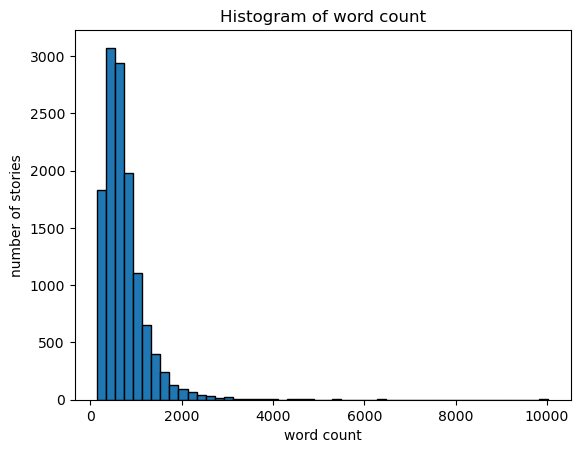

In [25]:
plt.hist(x=news_df['word_count'], bins=50, edgecolor='black')
plt.title('Histogram of word count')
plt.xlabel('word count')
plt.ylabel('number of stories')
plt.show()

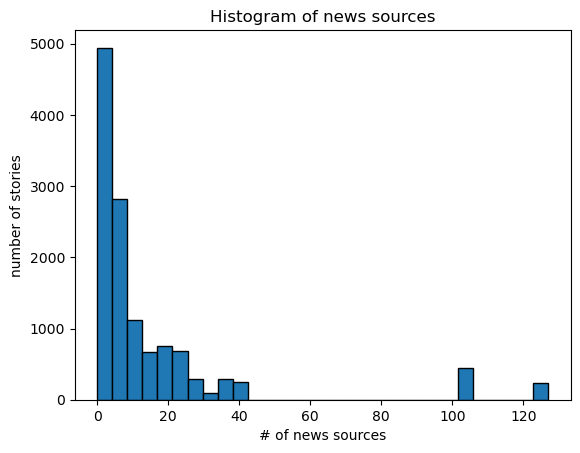

In [26]:
plt.hist(x=news_df['NewsOutlets2023'], bins=30, edgecolor='black')
plt.title('Histogram of news sources')
plt.xlabel('# of news sources')
plt.ylabel('number of stories')
plt.show()

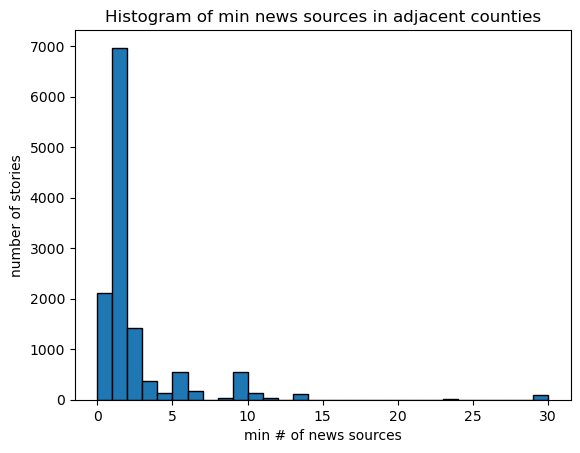

In [27]:
plt.hist(x=news_df['AdjCountyMin'], bins=30, edgecolor='black')
plt.title('Histogram of min news sources in adjacent counties')
plt.xlabel('min # of news sources')
plt.ylabel('number of stories')
plt.show()

In [28]:
news_df['news_partnership'].value_counts()

news_partnership
0.0    10362
1.0     2277
Name: count, dtype: int64

In [29]:
#average news sources in county and surounding county for each type of NP
NP_types = [0,1]
for type in NP_types:
    print(type)
    print(news_df['news_partnership'].value_counts()[type])
    print(news_df.loc[news_df['news_partnership']==type].mean(numeric_only=True, skipna=True))
    print(news_df.loc[news_df['news_partnership']==type]['source'].nunique())
    print('\n')

0
10362
sentiment_score       0.003199
news_partnership      0.000000
story_count          40.044779
NewsOutlets2023      14.404459
AdjCountyMin          2.089365
word_count          726.791160
news_status           0.158946
Adj_news_status       0.715113
LNA                   0.718008
dtype: float64
750


1
2277
sentiment_score       0.001852
news_partnership      1.000000
story_count          50.701801
NewsOutlets2023      16.913124
AdjCountyMin          2.156346
word_count          836.487484
news_status           0.065437
Adj_news_status       0.716733
LNA                   0.716733
dtype: float64
82




In [30]:
#how many are LNA or adj to one
news_df['LNA'].value_counts()

LNA
1    9112
0    3590
Name: count, dtype: int64

In [31]:
#how many are LNA
news_df['news_status'].value_counts()

news_status
0.0    10896
1.0     1806
Name: count, dtype: int64

In [32]:
#how many are adj. to LNA
news_df['Adj_news_status'].value_counts()

Adj_news_status
1.0    9082
0.0    3620
Name: count, dtype: int64

In [33]:
news_df[['news_partnership','LNA','news_status','Adj_news_status']].value_counts()

news_partnership  LNA  news_status  Adj_news_status
0.0               1    0.0          1.0                5793
                  0    0.0          0.0                2922
                  1    1.0          1.0                1617
1.0               1    0.0          1.0                1483
                  0    0.0          0.0                 645
                  1    1.0          1.0                 149
0.0               1    1.0          0.0                  30
Name: count, dtype: int64

## Preprocess the data

In [34]:
# create a series of the text
news_text = news_df['full_text']

In [35]:
#add writen numbers (i.e. one)
written_nums = []
for num in range(0,1000):
    written_nums.append(num2words(num))

In [36]:
#create stopwords
nltk_stopwords = stopwords.words('english')
#large list of stopswords
ND_stopwords = pd.read_csv('StopWords_GenericLong.txt', header=None)
ND_stopwords = ND_stopwords[0].to_list()
#combine them
large_stopwords = list(set(nltk_stopwords)) + list(set(ND_stopwords))
#remove ' and replace with ""
large_stopwords = [word.replace("'", "") for word in large_stopwords]

#these are the header for each text file so would apear a lot in the corpus and skew results
words_to_add = ['title','url','source','published','extracted']

custom_stopwords = large_stopwords + words_to_add + written_nums

In [37]:
#create list of institutions and publcations

#create list
institution_list = news_df['institution'].unique()
#remove nan
institution_list = [inst for inst in institution_list if str(inst) != 'nan']
#make lowercase
institution_list = [inst.lower() for inst in institution_list]
#remove punctuation
institution_list = [re.sub(r"[^\w\s]", " ", inst) for inst in institution_list]

#create list
publication_list = news_df['source'].unique()
#remove nan
publication_list = [pub for pub in publication_list if str(pub) != 'nan']
#make lowercase
publication_list = [pub.lower() for pub in publication_list]
#remove punctuation
publication_list = [re.sub(r"[^\w\s]", " ", pub) for pub in publication_list]


In [38]:
#make lowercase
news_text = news_text.str.lower()

#removes apostrophies
news_text = news_text.str.replace("'", "")

#remove non alphabet chars
news_text = news_text.str.replace(r"[^a-z\s]", " ", regex=True)

#remove links
news_text = news_text.str.replace(r"http\S+|www\.\S+", " ", regex=True)

#remove publication names and college names
for pub in publication_list:
    news_text = news_text.str.replace(pub, " ")

for inst in institution_list:
    news_text = news_text.str.replace(inst, " ")

#tokenize
news_text = news_text.str.split()

#remove stopwords and remove words <= 2 characters
news_text = news_text.apply(lambda x: [word for word in x if word not in custom_stopwords and len(word)>2])


In [39]:
news_text

0        [building, coming, back, palisades, photo, lis...
1        [sun, setting, solar, power, los, angeles, ima...
2        [crime, los, angeles, charts, murders, robbery...
3        [los, angeles, pool, party, coming, close, ima...
4        [streetlight, dark, tariff, years, law, enforc...
                               ...                        
12697    [spartan, logo, lives, lacrosse, practice, mil...
12698    [local, citizens, group, called, east, lansing...
12699    [june, dartmouth, divest, palestine, submitted...
12700    [jewelry, trends, change, gemstones, remain, p...
12701    [college, education, human, sciences, dean, re...
Name: full_text, Length: 12702, dtype: object

In [40]:
#add back to dataset
news_df['preprocessed_text'] = news_text

In [440]:
#test sentence to ensure code worked
sent_to_drop = "I go to Duke University and write for the 9th Street Journal."
#make lowercase
sent_to_drop = sent_to_drop.lower()

#removes apostrophies
sent_to_drop = sent_to_drop.replace("'", "")

#remove non alphabet chars
sent_to_drop = re.sub(r"[^a-z\s]", " ", sent_to_drop)

#remove links
sent_to_drop = re.sub(r"http\S+|www\.\S+", " ", sent_to_drop)

#remove publication names and college names
for pub in publication_list:
    sent_to_drop = sent_to_drop.replace(pub, " ")

for inst in institution_list:
    sent_to_drop = sent_to_drop.replace(inst, " ")

#tokenize
sent_to_drop = sent_to_drop.split()

#remove stopwords and remove words <= 2 characters
sent_to_drop = [word for word in sent_to_drop if word not in custom_stopwords and len(word)>2]

sent_to_drop

['write', 'street', 'journal']

In [494]:
news_text.to_pickle('news_text.pkl')

## Create LDA Model

### Tune the Model

##### For all of the below model tuning, we used the Vermont Advanced Computing Center (VACC) for additional computing power. All of the code we used is below, but the results were run seperatly and then uploaded from the VACC.

Pseudocoding k and alpha

create a list to hold the rows in
for asymetrical
    for every 10th value from 10 to 100:
        run a lda model with topics = k and alpha = asymetrical
        calculate the 2 coherence scores
        add new row with the correct values
repeat for symetrical 

create a table with columns alpha, k, umass, cv and rows as above

In [ ]:
#table
row_list = []
#this is what is in the loops and should be the values
row_list.append(["alpha", "k", "umass", "cv"])

table = pd.DataFrame(rows=row_list, columns=["alpha", "k", "umass", "cv"])

Pseudocode other three values

create list for each parameter
for the values
    run a lda model with corrcet parameters
    calculate coherence
    add to list
create table for each parameter

### Tune alpha and k

using smallest iterations and passes b/c indepedent and will run faster

#### First tuning for k and alpha

In [ ]:
# create a list to hold the rows in
row_list = []
# for asymetrical
#for every 10th value from 10 to 100:
for k in range(10,101,10):
#    run a lda model with topics = k and alpha = asymetrical
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, alpha='asymmetric',
                             iterations=10, passes=5, random_state=24)
#   calculate the 3 coherence scores
    coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
    coherence_lda_um = coherence_um.get_coherence()
    coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
    coherence_lda_cv = coherence_cv.get_coherence()
#    add new row with the correct values
    row_list.append(['asymmetric',k,coherence_lda_um,coherence_lda_cv])
# repeat for symetrical
for k in range(10,101,10):
#    run a lda model with topics = k and alpha = symetrical
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, alpha='symmetric',
                             iterations=10, passes=5, random_state=24)
#   calculate the 3 coherence scores
    coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
    coherence_lda_um = coherence_um.get_coherence()
    coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
    coherence_lda_cv = coherence_cv.get_coherence()
#    add new row with the correct values
    row_list.append(['symmetric',k,coherence_lda_um,coherence_lda_cv])


In [59]:
# create a table with columns alpha, k, umass, cv and rows as above
alpha_k_table = pd.DataFrame(row_list, columns=["alpha", "k", "umass", "cv"])

In [ ]:
#to save the table
alpha_k_table.to_pickle("alpha_k.pkl")

In [495]:
#imported from the VACC
alpha_k = pd.read_csv("alpha_k.csv")
#drop index row
alpha_k = alpha_k.drop(columns='Unnamed: 0')

The coherence scores do not agree for most of the values; the top 2 UMass scores were the bottom 2 Cv scores. The third highest UMass score was asymmetrical alpha with 20 topics which was the eighth highest Cv score. That is the first time there is any overlap between the two scores and balances them out.

In [496]:
alpha_k

,alpha,k,umass,cv
0,asymmetric,10,-1.037730,0.352531
1,asymmetric,20,-1.115258,0.373969
2,asymmetric,30,-1.184437,0.372465
3,asymmetric,40,-1.150377,0.367700
4,asymmetric,50,-1.155220,0.372678
5,asymmetric,60,-1.217651,0.377002
6,asymmetric,70,-1.294313,0.379372
7,asymmetric,80,-1.304506,0.375807
8,asymmetric,90,-1.365017,0.380996
9,asymmetric,100,-1.500334,0.367486


In [497]:
alpha_k.sort_values('umass', ascending=False)

,alpha,k,umass,cv
0,asymmetric,10,-1.037730,0.352531
10,symmetric,10,-1.039409,0.353807
1,asymmetric,20,-1.115258,0.373969
11,symmetric,20,-1.122230,0.370805
14,symmetric,50,-1.140346,0.370691
3,asymmetric,40,-1.150377,0.367700
13,symmetric,40,-1.152089,0.368087
4,asymmetric,50,-1.155220,0.372678
2,asymmetric,30,-1.184437,0.372465
15,symmetric,60,-1.201779,0.375160


In [498]:
alpha_k.sort_values('cv', ascending=False)

,alpha,k,umass,cv
18,symmetric,90,-1.315747,0.381685
8,asymmetric,90,-1.365017,0.380996
6,asymmetric,70,-1.294313,0.379372
5,asymmetric,60,-1.217651,0.377002
7,asymmetric,80,-1.304506,0.375807
15,symmetric,60,-1.201779,0.375160
16,symmetric,70,-1.278161,0.375064
1,asymmetric,20,-1.115258,0.373969
17,symmetric,80,-1.296736,0.373885
4,asymmetric,50,-1.155220,0.372678


#### find the best topic

In [ ]:
# create a list to hold the rows in
row_list = []
#for every value from 15 to 25:
for k in range(15,26,1):
#    run a lda model with topics = k and alpha = asymetrical
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, alpha='asymmetric',
                             iterations=10, passes=5, random_state=24)
#   calculate the 2 coherence scores
    coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
    coherence_lda_um = coherence_um.get_coherence()
    coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
    coherence_lda_cv = coherence_cv.get_coherence()
#    add new row with the correct values
    row_list.append(['asymmetric',k,coherence_lda_um,coherence_lda_cv])
best_k = pd.DataFrame(row_list, columns=["alpha", "k", "umass", "cv"])

In [ ]:
#to save the table
best_k.to_pickle('best_k.pkl')

In [499]:
#import from the VACC
best_k = pd.read_csv('best_k.csv')

The highest UMass coherence was for 22 topics which also had the second highest Cv coherence. The number of topics with the highest Cv is 20, which is the fourth highest for UMass. We decided 22 topics with an asymmetrical alpha was best for our corpus.

In [500]:
best_k

,alpha,k,umass,cv
0,asymmetric,15,-1.128895,0.361298
1,asymmetric,16,-1.121618,0.359173
2,asymmetric,17,-1.095945,0.357883
3,asymmetric,18,-1.120205,0.361787
4,asymmetric,19,-1.115967,0.363483
5,asymmetric,20,-1.115258,0.373969
6,asymmetric,21,-1.111167,0.370849
7,asymmetric,22,-1.091447,0.372006
8,asymmetric,23,-1.119261,0.370176
9,asymmetric,24,-1.143708,0.367244


In [501]:
best_k.sort_values('umass',ascending=False)

,alpha,k,umass,cv
7,asymmetric,22,-1.091447,0.372006
2,asymmetric,17,-1.095945,0.357883
6,asymmetric,21,-1.111167,0.370849
5,asymmetric,20,-1.115258,0.373969
4,asymmetric,19,-1.115967,0.363483
8,asymmetric,23,-1.119261,0.370176
3,asymmetric,18,-1.120205,0.361787
1,asymmetric,16,-1.121618,0.359173
0,asymmetric,15,-1.128895,0.361298
10,asymmetric,25,-1.132237,0.368215


In [502]:
best_k.sort_values('cv',ascending=False)

,alpha,k,umass,cv
5,asymmetric,20,-1.115258,0.373969
7,asymmetric,22,-1.091447,0.372006
6,asymmetric,21,-1.111167,0.370849
8,asymmetric,23,-1.119261,0.370176
10,asymmetric,25,-1.132237,0.368215
9,asymmetric,24,-1.143708,0.367244
4,asymmetric,19,-1.115967,0.363483
3,asymmetric,18,-1.120205,0.361787
0,asymmetric,15,-1.128895,0.361298
1,asymmetric,16,-1.121618,0.359173


### Finding iterations, passes, and chunk size

#### Iterations

In [ ]:
#iterations
row_list = []
for i in [10,50,100,500]:
#    run a lda model with topics = 20, alpha = asymetrical, and iterations = i
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=20, alpha='asymmetric',
                             iterations=i, passes=5, chunksize=10, random_state=24)
#   calculate the 2 coherence scores
    coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
    coherence_lda_um = coherence_um.get_coherence()
    coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
    coherence_lda_cv = coherence_cv.get_coherence()
#    add new row with the correct values
    row_list.append([i,coherence_lda_um,coherence_lda_cv])
best_it = pd.DataFrame(row_list, columns=["iterations", "umass", "cv"])

In [ ]:
#to save the table
best_it.to_pickle('best_it.pkl')

In [503]:
#import from the VACC
best_it = pd.read_csv('best_it.csv')
best_it = best_it.drop(columns=['Unnamed: 0'])

I chose 50 iterations. It scored the best for Cv and second best for UMass. 10 iterations was the best for UMass, but the worse for Cv.

In [504]:
best_it

,iterations,umass,cv
0,10,-1.091447,0.372006
1,50,-1.258724,0.406560
2,100,-1.339019,0.404888
3,500,-1.350122,0.400925


In [505]:
best_it.sort_values('umass',ascending=False)

,iterations,umass,cv
0,10,-1.091447,0.372006
1,50,-1.258724,0.406560
2,100,-1.339019,0.404888
3,500,-1.350122,0.400925


In [506]:
best_it.sort_values('cv',ascending=False)

,iterations,umass,cv
1,50,-1.258724,0.406560
2,100,-1.339019,0.404888
3,500,-1.350122,0.400925
0,10,-1.091447,0.372006


#### Passes

In [ ]:
#passes
row_list = []
for p in [5,10,50,100]:
#    run a lda model with topics = 20, alpha = asymetrical, and iterations = 50, passes=p
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=20, alpha='asymmetric',
                             iterations=50, passes=p, chunksize=10, random_state=24)
#   calculate the 2 coherence scores
    coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
    coherence_lda_um = coherence_um.get_coherence()
    coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
    coherence_lda_cv = coherence_cv.get_coherence()
#    add new row with the correct values
    row_list.append([p,coherence_lda_um,coherence_lda_cv])
best_pass = pd.DataFrame(row_list, columns=["passes", "umass", "cv"])

In [ ]:
#to save the table
best_pass.to_pickle('best_pass.pkl')

In [507]:
#import from the VACC
best_pass = pd.read_csv('best_pass.csv')

The UMass and Cv once again do not agree. The best Cv is the worse UMass and vice versa. They also do not agree on the second best number of passes. The difference between 10 and 50 passes for UMass is about 0.10 while the difference for Cv is about 0.08. Because the difference is large for UMass I went with the second highest coherence UMass score as the best model which was 10 passes.

In [508]:
best_pass

,passes,umass,cv
0,5,-1.258724,0.406560
1,10,-1.627142,0.440920
2,50,-1.729740,0.521436
3,100,-1.730588,0.540503


In [509]:
best_pass.sort_values('umass', ascending=False)

,passes,umass,cv
0,5,-1.258724,0.406560
1,10,-1.627142,0.440920
2,50,-1.729740,0.521436
3,100,-1.730588,0.540503


In [510]:
best_pass.sort_values('cv', ascending=False)

,passes,umass,cv
3,100,-1.730588,0.540503
2,50,-1.729740,0.521436
1,10,-1.627142,0.440920
0,5,-1.258724,0.406560


#### Chunk Size

In [ ]:
#chunk size
row_list = []
for c in [10,50,100,500]:
#    run a lda model with topics=20, alpha=asymetrical, and iterations=50, passes=100, chunk=c
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=20, alpha='asymmetric',
                             iterations=50, passes=100, chunksize=c, random_state=24)
#   calculate the 2 coherence scores
    coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
    coherence_lda_um = coherence_um.get_coherence()
    coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
    coherence_lda_cv = coherence_cv.get_coherence()
#    add new row with the correct values
    row_list.append([c,coherence_lda_um,coherence_lda_cv])
best_chunk = pd.DataFrame(row_list, columns=["chunk size", "umass", "cv"])

In [ ]:
#to save the table
best_chunk.to_pickle('best_chunk.pkl')

In [511]:
#import from the VACC
best_chunk = pd.read_csv('best_chunk.csv')

A chunk size of 100 has the highest Umass, but the lowest Cv coherence. The highest chunk size for Cv is 500 which is only the second lowest UMass. Because of this we went with 500 as the chunk size.

In [512]:
best_chunk

,chunk size,umass,cv
0,10,-1.548837,0.407432
1,50,-1.318503,0.386368
2,100,-1.270137,0.377651
3,500,-1.394262,0.411794


In [513]:
best_chunk.sort_values('umass', ascending=False)

,chunk size,umass,cv
2,100,-1.270137,0.377651
1,50,-1.318503,0.386368
3,500,-1.394262,0.411794
0,10,-1.548837,0.407432


In [514]:
best_chunk.sort_values('cv', ascending=False)

,chunk size,umass,cv
3,500,-1.394262,0.411794
0,10,-1.548837,0.407432
1,50,-1.318503,0.386368
2,100,-1.270137,0.377651


## Final LDA Model

While a random seed is set, the model, coherence, and topics change each time it is run. These may not be the topics used in our analysis, but the top 5 words and 2 most representative articles can be found in Appendix C.

In [41]:
#create a dictionary
dictionary = Dictionary(news_text)
print('Number of unique words in initial documents:', len(dictionary))

#filter out extream tokens
dictionary.filter_extremes(no_below=5, no_above=0.90)
print('Number of unique words after removing rare and common words: ', len(dictionary))

Number of unique words in initial documents: 105296
Number of unique words after removing rare and common words:  30326


In [42]:
#bag-of-words corous
corpus = [dictionary.doc2bow(text) for text in news_text]

In [43]:
print('Number of unique tokens: %d' % len(dictionary))
print('Number of documents: %d' % len(corpus))

Number of unique tokens: 30326
Number of documents: 12702


In [44]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=22, alpha='asymmetric',
                             iterations=50, passes=10, chunksize=500, random_state=24)

#### Coherence scores

In [45]:
coherence_cv = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="c_v")
coherence_lda_cv = coherence_cv.get_coherence()
print('\nCoherence Score (c_v): ', coherence_lda_cv)
coherence_um = CoherenceModel(model=lda_model, texts=news_text, dictionary=dictionary, coherence="u_mass")
coherence_lda_um = coherence_um.get_coherence()
print('\nCoherence Score (umass): ', coherence_lda_um)


Coherence Score (c_v):  0.44779355432453394

Coherence Score (umass):  -2.056884463705558


In [46]:
lda_model.print_topics(num_words=10, num_topics=22)

[(0,
  '0.011*"paul" + 0.008*"yeah" + 0.007*"abortion" + 0.007*"snow" + 0.005*"kassandra" + 0.005*"leopards" + 0.005*"state" + 0.004*"illinois" + 0.004*"abby" + 0.004*"people"'),
 (1,
  '0.014*"people" + 0.012*"community" + 0.010*"city" + 0.005*"history" + 0.005*"queer" + 0.005*"years" + 0.004*"local" + 0.004*"native" + 0.004*"year" + 0.004*"land"'),
 (2,
  '0.012*"people" + 0.007*"community" + 0.004*"fashion" + 0.004*"year" + 0.004*"time" + 0.004*"waste" + 0.003*"health" + 0.003*"environmental" + 0.003*"make" + 0.003*"living"'),
 (3,
  '0.014*"draft" + 0.012*"pick" + 0.007*"nfl" + 0.007*"msu" + 0.006*"selection" + 0.005*"year" + 0.005*"team" + 0.005*"board" + 0.005*"state" + 0.005*"nevada"'),
 (4,
  '0.011*"campus" + 0.007*"building" + 0.006*"housing" + 0.005*"los" + 0.005*"students" + 0.005*"hall" + 0.004*"safety" + 0.004*"con" + 0.004*"weather" + 0.004*"city"'),
 (5,
  '0.016*"students" + 0.008*"art" + 0.007*"community" + 0.006*"student" + 0.005*"work" + 0.005*"people" + 0.005*"even

Add the topic proportions back into the dataframe

In [ ]:
#creates a documnet topic matrix
doc_topic_matrix = gensim.matutils.corpus2csc(lda_model.get_document_topics(corpus)).T.toarray()
#turns it into a dataframe
topic_df = pd.DataFrame(doc_topic_matrix)
topic_df.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.0,0.000000,0.0,0.0,0.587529,0.0,0.014135,0.091822,0.0,0.000000,...,0.131311,0.0,0.0,0.010854,0.0,0.0,0.000000,0.127253,0.000000,0.0
1,0.0,0.000000,0.0,0.0,0.539099,0.0,0.000000,0.180163,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
2,0.0,0.051467,0.0,0.0,0.387527,0.0,0.000000,0.000000,0.0,0.000000,...,0.449858,0.0,0.0,0.000000,0.0,0.0,0.061384,0.000000,0.000000,0.0
3,0.0,0.074829,0.0,0.0,0.574325,0.0,0.000000,0.119324,0.0,0.073595,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.046345,0.000000,0.023441,0.0
4,0.0,0.000000,0.0,0.0,0.647326,0.0,0.000000,0.103446,0.0,0.000000,...,0.187431,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0


In [48]:
#add it to the dataframe
topic_news_df = pd.concat([news_df.reset_index(drop=True),topic_df.reset_index(drop=True)], axis=1)
topic_news_df.head(3)

,source,title,link,published,captured_at,theme,keywords,sentiment_label,sentiment_score,extraction_status,...,12,13,14,15,16,17,18,19,20,21
0,Crosstown,Building is coming back in the Palisades,https://xtown.la/2025/09/30/building-pacific-p...,"Tue, 30 Sep 2025 20:59:27 +0000",2026-02-03 11:52:48,Unclassified,building | coming | back | palisades,neutral,0.0,ok,...,0.131311,0.0,0.0,0.010854,0.0,0.0,0.000000,0.127253,0.0,0.0
1,Crosstown,Sun is setting on new solar power in Los Angeles,https://xtown.la/2025/09/11/solar-power-los-an...,"Fri, 12 Sep 2025 02:08:41 +0000",2026-02-03 11:52:48,Conference | Collegiate | Transition | Initiat...,setting | solar | power | angeles,neutral,0.0,ok,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
2,Crosstown,Crime in Los Angeles in four charts,https://xtown.la/2025/08/25/crime-in-los-angel...,"Mon, 25 Aug 2025 15:30:11 +0000",2026-02-03 11:52:48,Unclassified,crime | angeles | four | charts,neutral,0.0,ok,...,0.449858,0.0,0.0,0.000000,0.0,0.0,0.061384,0.000000,0.0,0.0


#### Labeling the topics

In [49]:
#for each topic
for topic in range(0,22,1):
    print(topic+1)
#print out the top 50 words
    print(lda_model.print_topic(topic, topn=50))
#print out info about the top 2 most representaive documents (to be read on their website)
    print(topic_news_df.sort_values(by=[topic], ascending=False).iloc[0,[1,2]])
    print(topic_news_df.sort_values(by=[topic], ascending=False).iloc[1,[1,2]])
    print('\n')

1
0.011*"paul" + 0.008*"yeah" + 0.007*"abortion" + 0.007*"snow" + 0.005*"kassandra" + 0.005*"leopards" + 0.005*"state" + 0.004*"illinois" + 0.004*"abby" + 0.004*"people" + 0.003*"day" + 0.003*"care" + 0.003*"back" + 0.003*"black" + 0.003*"nku" + 0.003*"women" + 0.003*"season" + 0.003*"patients" + 0.003*"weather" + 0.003*"family" + 0.003*"pregnancy" + 0.003*"temperatures" + 0.003*"celeste" + 0.003*"time" + 0.003*"make" + 0.003*"june" + 0.003*"david" + 0.003*"monday" + 0.003*"week" + 0.003*"health" + 0.002*"naruto" + 0.002*"storm" + 0.002*"sunday" + 0.002*"crazy" + 0.002*"hair" + 0.002*"maternal" + 0.002*"farm" + 0.002*"high" + 0.002*"case" + 0.002*"saturday" + 0.002*"hospital" + 0.002*"lake" + 0.002*"year" + 0.002*"birth" + 0.002*"cows" + 0.002*"body" + 0.002*"made" + 0.002*"april" + 0.002*"cold" + 0.002*"weekend"
title           Certified Chismosas Podcast: The D4vd case
link     https://www.talonmarks.com/multimedia/2026/05/...
Name: 11491, dtype: object
title                     Iowa

### Aggregate the Topics

#### CIN and CC

In [51]:
cin_cc_df = topic_news_df.drop(columns=['published','captured_at','theme','keywords','sentiment_label','sentiment_score','extraction_status'
                                        ,'full_text_path','slug','corpus_file','CITY','preprocessed_text'])

In [52]:
cin_cc_df['CIN'] = cin_cc_df[2]+cin_cc_df[4]+cin_cc_df[7]+cin_cc_df[10]+cin_cc_df[11]+cin_cc_df[12]+cin_cc_df[13]+cin_cc_df[16]
cin_cc_df['Community'] = cin_cc_df[1]+cin_cc_df[3]+cin_cc_df[5]+cin_cc_df[6]+cin_cc_df[8]+cin_cc_df[9]+cin_cc_df[14]+cin_cc_df[17]+cin_cc_df[18]+cin_cc_df[19]+cin_cc_df[20]+cin_cc_df[21]
cin_cc_df['Mixed'] = cin_cc_df[0] + cin_cc_df[15]

In [53]:
cin_cc_df = cin_cc_df.drop(columns=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19, 20,21])

In [54]:
cin_cc_df.head()

,source,title,link,full_text,institution,news_partnership,story_count,NewsOutlets2023,AdjCountyMin,word_count,news_status,Adj_news_status,LNA,CIN,Community,Mixed
0,Crosstown,Building is coming back in the Palisades,https://xtown.la/2025/09/30/building-pacific-p...,Building is coming back in the Palisades\n(Pho...,University of Southern California,1.0,14.0,104.0,9.0,920,0.0,0.0,0,0.846122,0.141388,0.010854
1,Crosstown,Sun is setting on new solar power in Los Angeles,https://xtown.la/2025/09/11/solar-power-los-an...,Sun is setting on new solar power in Los Angel...,University of Southern California,1.0,14.0,104.0,9.0,1298,0.0,0.0,0,0.998607,0.000000,0.000000
2,Crosstown,Crime in Los Angeles in four charts,https://xtown.la/2025/08/25/crime-in-los-angel...,"Crime in Los Angeles in four charts\nMurders, ...",University of Southern California,1.0,14.0,104.0,9.0,669,0.0,0.0,0,0.875775,0.112851,0.000000
3,Crosstown,Los Angeles’s pool party may be coming to a close,https://xtown.la/2025/08/18/pool-permits-los-a...,Los Angeles’s pool party may be coming to a cl...,University of Southern California,1.0,14.0,104.0,9.0,406,0.0,0.0,0,0.769984,0.218210,0.000000
4,Crosstown,Your streetlight went dark. Could a new tariff...,https://xtown.la/2025/08/06/copper-wire-tarrif...,Your streetlight went dark. Could a new tariff...,University of Southern California,1.0,14.0,104.0,9.0,735,0.0,0.0,0,0.997713,0.000000,0.000000


In [56]:
ccc_grouped = cin_cc_df[['news_partnership','LNA','CIN','Community','Mixed']].groupby(['news_partnership','LNA']).mean()
ccc_grouped

CIN  Community     Mixed
news_partnership LNA                               
0.0              0    0.212520   0.749313  0.033600
                 1    0.204513   0.777356  0.013276
1.0              0    0.562768   0.417731  0.014892
                 1    0.455701   0.523249  0.016330

In [57]:
ccc_gb_lna = cin_cc_df[['LNA','CIN','Community','Mixed']].groupby('LNA').mean()
ccc_gb_lna

,CIN,Community,Mixed
LNA,,,
0,0.275688,0.689711,0.030027
1,0.249747,0.731638,0.013781


In [58]:
ccc_gb_np = cin_cc_df[['news_partnership','CIN','Community','Mixed']].groupby(['news_partnership']).mean()
ccc_gb_np

,CIN,Community,Mixed
news_partnership,,,
0.0,0.206771,0.769448,0.019008
1.0,0.486030,0.493359,0.015923


#### Metatopics

In [59]:
meta_df = topic_news_df.drop(columns=['published','captured_at','theme','keywords','sentiment_label','sentiment_score','extraction_status'
                                        ,'full_text_path','slug','corpus_file','CITY','preprocessed_text'])

In [60]:
#CIN
meta_df['Emergencies'] = meta_df[12]
meta_df['Environment/Planning'] = meta_df[4]+meta_df[10]
meta_df['Health'] = meta_df[2]+meta_df[7]
meta_df['Politics'] = meta_df[11]+meta_df[16]
meta_df['Education'] = meta_df[13]

#Community Cohesion
meta_df['Sports'] = meta_df[6]+meta_df[18]
meta_df['Campus'] = meta_df[19]
meta_df['Arts'] = meta_df[3]+meta_df[9]
meta_df['STEM'] = meta_df[8]
meta_df['People/Relationships'] = meta_df[1]+meta_df[17]
meta_df['Events'] = meta_df[5]+meta_df[14]+meta_df[21]

#Other
meta_df['None'] = meta_df[0]+meta_df[15]+meta_df[20]

In [61]:
meta_df = meta_df.drop(columns=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21])

In [62]:
meta_df.head()

,source,title,link,full_text,institution,news_partnership,story_count,NewsOutlets2023,AdjCountyMin,word_count,...,Health,Politics,Education,Sports,Campus,Arts,STEM,People/Relationships,Events,None
0,Crosstown,Building is coming back in the Palisades,https://xtown.la/2025/09/30/building-pacific-p...,Building is coming back in the Palisades\n(Pho...,University of Southern California,1.0,14.0,104.0,9.0,920,...,0.091822,0.000000,0.0,0.014135,0.127253,0.000000,0.0,0.000000,0.0,0.010854
1,Crosstown,Sun is setting on new solar power in Los Angeles,https://xtown.la/2025/09/11/solar-power-los-an...,Sun is setting on new solar power in Los Angel...,University of Southern California,1.0,14.0,104.0,9.0,1298,...,0.180163,0.252645,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
2,Crosstown,Crime in Los Angeles in four charts,https://xtown.la/2025/08/25/crime-in-los-angel...,"Crime in Los Angeles in four charts\nMurders, ...",University of Southern California,1.0,14.0,104.0,9.0,669,...,0.000000,0.000000,0.0,0.061384,0.000000,0.000000,0.0,0.051467,0.0,0.000000
3,Crosstown,Los Angeles’s pool party may be coming to a close,https://xtown.la/2025/08/18/pool-permits-los-a...,Los Angeles’s pool party may be coming to a cl...,University of Southern California,1.0,14.0,104.0,9.0,406,...,0.119324,0.076335,0.0,0.046345,0.000000,0.073595,0.0,0.074829,0.0,0.023441
4,Crosstown,Your streetlight went dark. Could a new tariff...,https://xtown.la/2025/08/06/copper-wire-tarrif...,Your streetlight went dark. Could a new tariff...,University of Southern California,1.0,14.0,104.0,9.0,735,...,0.103446,0.059510,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


In [63]:
meta_gb = meta_df.loc[:,~meta_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status'])].groupby(['news_partnership','LNA']).mean(numeric_only=True)
meta_gb

Emergencies  Environment/Planning    Health  Politics  \
news_partnership LNA                                                          
0.0              0       0.039660              0.035931  0.051640  0.074598   
                 1       0.034020              0.043882  0.048964  0.066902   
1.0              0       0.093279              0.097957  0.131306  0.210240   
                 1       0.098465              0.062108  0.102475  0.170842   

                      Education    Sports    Campus      Arts      STEM  \
news_partnership LNA                                                      
0.0              0     0.010691  0.127826  0.124605  0.098135  0.070784   
                 1     0.010746  0.155523  0.107946  0.105421  0.061704   
1.0              0     0.029986  0.029337  0.043454  0.037601  0.043307   
                 1     0.021812  0.128457  0.041752  0.049024  0.057779   

                      People/Relationships    Events      None  
news_partnership LNA                                            
0.0              0                0.154720  0.162885  0.043959  
                 1                0.156331  0.184726  0.018980  
1.0              0                0.138391  0.120566  0.019966  
                 1                0.120226  0.121089  0.021252

In [64]:
meta_np = meta_df.loc[:,~meta_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status','LNA'])].groupby('news_partnership').mean(numeric_only=True)
meta_np

,Emergencies,Environment/Planning,Health,Politics,Education,Sports,Campus,Arts,STEM,People/Relationships,Events,None
news_partnership,,,,,,,,,,,,
0.0,0.035610,0.041640,0.049718,0.069072,0.010731,0.147713,0.112643,0.103367,0.064265,0.155877,0.178567,0.026024
1.0,0.096996,0.072262,0.110642,0.182003,0.024127,0.100380,0.042234,0.045788,0.053680,0.125372,0.120941,0.020888


In [65]:
meta_lna = meta_df.loc[:,~meta_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status','news_partnership'])].groupby('LNA').mean(numeric_only=True)
meta_lna

,Emergencies,Environment/Planning,Health,Politics,Education,Sports,Campus,Arts,STEM,People/Relationships,Events,None
LNA,,,,,,,,,,,,
0,0.049169,0.047119,0.065921,0.099346,0.014132,0.110386,0.109807,0.087025,0.065668,0.151511,0.155905,0.039438
1,0.045596,0.047119,0.058737,0.085602,0.012693,0.150578,0.096068,0.095184,0.061317,0.149696,0.173245,0.019332


#### IPTC Topic Codes

In [76]:
iptc_df = topic_news_df.drop(columns=['published','captured_at','theme','keywords','sentiment_label','sentiment_score','extraction_status'
                                        ,'full_text_path','slug','corpus_file','CITY','preprocessed_text'])

In [77]:
#community
iptc_df['arts/media'] = iptc_df[5]+iptc_df[8]+iptc_df[9]
iptc_df['sports'] = iptc_df[3]+iptc_df[6]+iptc_df[7]+iptc_df[18]
iptc_df['education'] = iptc_df[13]+iptc_df[19]
iptc_df['lifestyle'] = iptc_df[14]+iptc_df[20]
iptc_df['society'] = iptc_df[1]+iptc_df[17]
#CIN
iptc_df['economy'] = iptc_df[4]
iptc_df['politics'] = iptc_df[11]+iptc_df[16]
iptc_df['crime'] = iptc_df[12]
iptc_df['environment'] = iptc_df[2]+iptc_df[10]
#None
iptc_df['none'] = iptc_df[0]+iptc_df[15]+iptc_df[20]

In [78]:
iptc_df = iptc_df.drop(columns=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21])

In [79]:
iptc_df.head()

,source,title,link,full_text,institution,news_partnership,story_count,NewsOutlets2023,AdjCountyMin,word_count,...,arts/media,sports,education,lifestyle,society,economy,politics,crime,environment,none
0,Crosstown,Building is coming back in the Palisades,https://xtown.la/2025/09/30/building-pacific-p...,Building is coming back in the Palisades\n(Pho...,University of Southern California,1.0,14.0,104.0,9.0,920,...,0.000000,0.105957,0.127253,0.000000,0.000000,0.587529,0.000000,0.131311,0.03546,0.010854
1,Crosstown,Sun is setting on new solar power in Los Angeles,https://xtown.la/2025/09/11/solar-power-los-an...,Sun is setting on new solar power in Los Angel...,University of Southern California,1.0,14.0,104.0,9.0,1298,...,0.000000,0.180163,0.000000,0.000000,0.000000,0.539099,0.252645,0.000000,0.02670,0.000000
2,Crosstown,Crime in Los Angeles in four charts,https://xtown.la/2025/08/25/crime-in-los-angel...,"Crime in Los Angeles in four charts\nMurders, ...",University of Southern California,1.0,14.0,104.0,9.0,669,...,0.000000,0.061384,0.000000,0.000000,0.051467,0.387527,0.000000,0.449858,0.03839,0.000000
3,Crosstown,Los Angeles’s pool party may be coming to a close,https://xtown.la/2025/08/18/pool-permits-los-a...,Los Angeles’s pool party may be coming to a cl...,University of Southern California,1.0,14.0,104.0,9.0,406,...,0.073595,0.165669,0.000000,0.023441,0.074829,0.574325,0.076335,0.000000,0.00000,0.023441
4,Crosstown,Your streetlight went dark. Could a new tariff...,https://xtown.la/2025/08/06/copper-wire-tarrif...,Your streetlight went dark. Could a new tariff...,University of Southern California,1.0,14.0,104.0,9.0,735,...,0.000000,0.103446,0.000000,0.000000,0.000000,0.647326,0.059510,0.187431,0.00000,0.000000


In [80]:
iptc_gb = iptc_df.loc[:,~iptc_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status'])].groupby(['news_partnership','LNA']).mean(numeric_only=True)
iptc_gb

arts/media    sports  education  lifestyle   society  \
news_partnership LNA                                                         
0.0              0      0.240909  0.170019   0.135296   0.054260  0.154720   
                 1      0.257643  0.194553   0.118692   0.049349  0.156331   
1.0              0      0.124911  0.128689   0.073440   0.058280  0.138391   
                 1      0.144734  0.211647   0.063563   0.046370  0.120226   

                       economy  politics     crime  environment      none  
news_partnership LNA                                                       
0.0              0    0.024498  0.074598  0.039660     0.034084  0.043959  
                 1    0.024864  0.066902  0.034020     0.038693  0.018980  
1.0              0    0.079183  0.210240  0.093279     0.055223  0.019966  
                 1    0.049068  0.170842  0.098465     0.044965  0.021252

In [81]:
iptc_np = iptc_df.loc[:,~iptc_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status','LNA'])].groupby(['news_partnership']).mean(numeric_only=True)
iptc_np

,arts/media,sports,education,lifestyle,society,economy,politics,crime,environment,none
news_partnership,,,,,,,,,,
0.0,0.252924,0.187634,0.123374,0.050734,0.155877,0.024761,0.069072,0.035610,0.037393,0.026024
1.0,0.139119,0.188148,0.066361,0.049744,0.125372,0.057598,0.182003,0.096996,0.047871,0.020888


In [82]:
iptc_lna = iptc_df.loc[:,~iptc_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status','news_partnership'])].groupby('LNA').mean(numeric_only=True)
iptc_lna

,arts/media,sports,education,lifestyle,society,economy,politics,crime,environment,none
LNA,,,,,,,,,,
0,0.220479,0.162735,0.123939,0.054766,0.151511,0.034384,0.099346,0.049169,0.037903,0.039438
1,0.237576,0.197552,0.108761,0.048746,0.149696,0.029171,0.085602,0.045596,0.039932,0.019332


#### College Words

In [85]:
college_df = topic_news_df.drop(columns=['published','captured_at','theme','keywords','sentiment_label','sentiment_score','extraction_status'
                                        ,'full_text_path','slug','corpus_file','CITY','preprocessed_text'])

In [86]:
college_df['yes'] = college_df[2]+college_df[3]+college_df[4]+college_df[5]+college_df[6]+college_df[8]+college_df[10]+college_df[13]+college_df[14]+college_df[17]+college_df[18]+college_df[19]+college_df[20]+college_df[21]
college_df['no'] = college_df[0]+college_df[1]+college_df[7]+college_df[9]+college_df[11]+college_df[12]+college_df[15]+college_df[16]

In [87]:
college_df = college_df.drop(columns=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21])

In [88]:
college_df.head()

,source,title,link,full_text,institution,news_partnership,story_count,NewsOutlets2023,AdjCountyMin,word_count,news_status,Adj_news_status,LNA,yes,no
0,Crosstown,Building is coming back in the Palisades,https://xtown.la/2025/09/30/building-pacific-p...,Building is coming back in the Palisades\n(Pho...,University of Southern California,1.0,14.0,104.0,9.0,920,0.0,0.0,0,0.764376,0.233988
1,Crosstown,Sun is setting on new solar power in Los Angeles,https://xtown.la/2025/09/11/solar-power-los-an...,Sun is setting on new solar power in Los Angel...,University of Southern California,1.0,14.0,104.0,9.0,1298,0.0,0.0,0,0.565799,0.432808
2,Crosstown,Crime in Los Angeles in four charts,https://xtown.la/2025/08/25/crime-in-los-angel...,"Crime in Los Angeles in four charts\nMurders, ...",University of Southern California,1.0,14.0,104.0,9.0,669,0.0,0.0,0,0.487301,0.501325
3,Crosstown,Los Angeles’s pool party may be coming to a close,https://xtown.la/2025/08/18/pool-permits-los-a...,Los Angeles’s pool party may be coming to a cl...,University of Southern California,1.0,14.0,104.0,9.0,406,0.0,0.0,0,0.644111,0.344083
4,Crosstown,Your streetlight went dark. Could a new tariff...,https://xtown.la/2025/08/06/copper-wire-tarrif...,Your streetlight went dark. Could a new tariff...,University of Southern California,1.0,14.0,104.0,9.0,735,0.0,0.0,0,0.647326,0.350387


In [ ]:
college_df.loc[:,~college_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status'])].groupby(['news_partnership','LNA']).mean(numeric_only=True)

yes        no
news_partnership LNA                    
0.0              0    0.706163  0.289271
                 1    0.727312  0.267833
1.0              0    0.461041  0.534351
                 1    0.536718  0.458562

In [94]:
college_df.loc[:,~college_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status','news_partnership'])].groupby(['LNA']).mean(numeric_only=True)

,yes,no
LNA,,
0,0.662370,0.333056
1,0.693127,0.302039


In [95]:
college_df.loc[:,~college_df.columns.isin(['story_count','NewsOutlets2023','AdjCountyMin','word_count','news_status','Adj_news_status','LNA'])].groupby(['news_partnership']).mean(numeric_only=True)

,yes,no
news_partnership,,
0.0,0.721348,0.273878
1.0,0.515281,0.480031


Colleges and CINs

In [105]:
college_ccc = pd.DataFrame({'Topic': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22], 
                                    'College Words':['no','no','yes','yes','yes','yes','yes','no','yes','no','yes','no','no','yes','yes','no','no','yes','yes','yes','yes','yes'], 
                                    'CIN status': ['mix','com','cin','com','cin','com','com','cin','com','com','cin','cin','cin','cin','com','mix','cin','com','com','com','com','com']})

In [108]:
college_ccc[['CIN status','College Words']].value_counts()

CIN status  College Words
com         yes              10
cin         no                4
            yes               4
com         no                2
mix         no                2
Name: count, dtype: int64

10/12 COM topics have college words while only 4/8 CIN topics have college words and no mixed topics have college words. This means We were right to claim that the com topics may be about the campus more so than the CIN ones are.

#### Export the tables for viz

In [83]:
cin_cc_df.to_pickle("cin_cc_df")
ccc_grouped.to_pickle("cc_gb.pkl")
ccc_gb_lna.to_pickle("cc_gb_lna.pkl")
ccc_gb_np.to_pickle("cc_gb_np.pkl")

meta_df.to_pickle('meta_df.pkl')
meta_gb.to_pickle("meta_gb.pkl")
meta_lna.to_pickle("meta_gb_lna.pkl")
meta_np.to_pickle("meta_gb_np.pkl")

iptc_df.to_pickle("iptc_df.pkl")
iptc_gb.to_pickle("iptc_gb.pkl")
iptc_lna.to_pickle("iptc_gb_lna.pkl")
iptc_np.to_pickle("iptc_gb_np.pkl")
